> Las redes recurrentes simples (RNN) a menudo olvidan el contexto inicial cuando la oración es larga. Las capas Bidirectional LSTM leen el texto de izquierda a derecha y viceversa



# Preprocesamiento de los datos 

1. Normalizar los datos -> Todo minusculas, quitar caracteres especiales 
2. Eliminar STOP WORD (conectores)
3. Entrenar la misma configuracion neuronal 
4. Aplicar Lematizacion a los datos sin STOP WORDS 
5. Entrenar la misma configuracion de red neuronal

In [64]:
import pandas as pd 
import numpy as np
import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import keras
import re
import unicodedata
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from tensorflow.keras.callbacks import EarlyStopping

In [37]:
df = pd.read_csv('IMDB Dataset.csv')
print(df.head())

print ("----------------------")
print(f"Total: \n{df['sentiment'].value_counts()}")

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
----------------------
Total: 
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [38]:
def comparar (df):
    print("--- Comparativa de resultados ---")
    print(df[['review', 'review_limpia']].head())
    df['review'] = df['review_limpia']
    df.drop(columns=['review_limpia'], inplace=True)

## Normalizar los datos

In [39]:
def normalize_text(text):
    # 1. Convertir a minúsculas
    text = text.lower()
    
    # 2. Eliminar acentos (Convertir 'á' en 'a')
    # Normalizamos a forma NFD y luego descartamos los caracteres de acentuación
    text = unicodedata.normalize('NFD', text)
    text = text.encode('ascii', 'ignore').decode("utf-8")
    
    # 3. Eliminar caracteres especiales
    # Mantenemos solo letras (a-z), números (0-9) y espacios (\s)
    # El símbolo '^' significa "todo lo que NO sea esto"
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    return text

In [40]:
df['review_limpia'] = df['review'].apply(normalize_text)
comparar(df)


--- Comparativa de resultados ---
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                       review_limpia  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production br br the filmin...  
2  i thought this was a wonderful way to spend ti...  
3  basically theres a family where a little boy j...  
4  petter matteis love in the time of money is a ...  


## Eliminar STOP WORDS

In [41]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    return " ".join(filtered_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\714KQ54\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [42]:
df['review_limpia'] = df['review'].apply(remove_stopwords)
comparar(df)

--- Comparativa de resultados ---
                                              review  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production br br the filmin...   
2  i thought this was a wonderful way to spend ti...   
3  basically theres a family where a little boy j...   
4  petter matteis love in the time of money is a ...   

                                       review_limpia  
0  one reviewers mentioned watching 1 oz episode ...  
1  wonderful little production br br filming tech...  
2  thought wonderful way spend time hot summer we...  
3  basically theres family little boy jake thinks...  
4  petter matteis love time money visually stunni...  


# Entrenar RNA sin Lematización


### Codificar las variables

In [43]:
review = []
sentences = list(df['review'])
for sentence in sentences:
    review.append(sentence)

labels = df['sentiment']
labels = np.array(list(map(lambda x: 1 if x == 'positive' else 0, labels)))

### Dividir entre entrenamiento y prueba


In [44]:
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.2, random_state=42)

#Parametros 
vocab_size = 1000
max_length = 120
embedding_dim = 16
trunc_type = 'post'
oov_tok = "<OOV>"

### Tokenizar las palabras 

In [46]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences, maxlen=max_length, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type)

### Construir el modelo

In [63]:
model = models.Sequential([
    layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    # Bidirectional permite contexto en ambas direcciones
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    # GlobalAveragePooling ayuda a reducir dimensiones y evita el sobreajuste
    layers.GlobalAveragePooling1D(),
    # Dropout es vital para evitar el sobreajuste (overfitting)
    layers.Dropout(0.5),
    layers.Dense(24, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Clasificación binaria (sentimiento)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\714KQ54\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo 

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.7677 - loss: 0.4759 - val_accuracy: 0.8191 - val_loss: 0.3947
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.8298 - loss: 0.3852 - val_accuracy: 0.8390 - val_loss: 0.3623
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8418 - loss: 0.3596 - val_accuracy: 0.8354 - val_loss: 0.3607
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8481 - loss: 0.3487 - val_accuracy: 0.8394 - val_loss: 0.3586
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8522 - loss: 0.3404 - val_accuracy: 0.8445 - val_loss: 0.3467
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.8563 - loss: 0.3319 - val_accuracy: 0.8451 - val_loss: 0.3457
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.8608 - loss: 0.3238 - val_accuracy: 0.8407 - val_loss: 0.3516
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - accuracy: 0.8625 -

<Axes: >

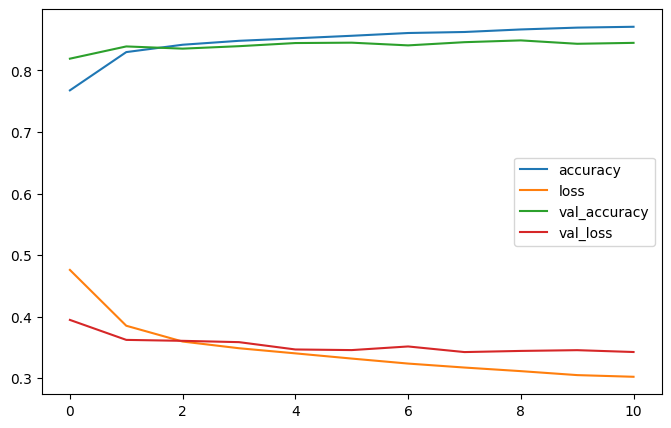

In [68]:
callback_early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(padded, 
                    train_labels,epochs=20, 
                    validation_data=(test_padded, test_labels),
                    callbacks=[callback_early])
pd.DataFrame(history.history).plot(figsize=(8,5))

# Entrenar RNA con Lematización

La lematización es un paso más avanzado que la limpieza básica. Mientras que el stemming simplemente corta los sufijos de las palabras (lo cual suele generar errores), la lematización utiliza un diccionario y análisis morfológico para devolver la palabra a su raíz (su "lema").
Por ejemplo:

- "Running" -> "Run"

- "Better" -> "Good"

- "Children" -> "Child"

Para esto usaremos `WordNetLemmatizer` de NLTK.

### Lematizar las frases

In [49]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    #Mapea las etiquetas POS de nltk a las que entiende WordNet
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in words]
    return " ".join(lemmatized_words)



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\714KQ54\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\714KQ54\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\714KQ54\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [51]:
df_lematizado = df.copy()
df_lematizado['review_limpia'] = df_lematizado['review'].apply(lemmatize_text)
comparar(df_lematizado)

--- Comparativa de resultados ---
                                              review  \
0  one reviewers mentioned watching 1 oz episode ...   
1  wonderful little production br br filming tech...   
2  thought wonderful way spend time hot summer we...   
3  basically theres family little boy jake thinks...   
4  petter matteis love time money visually stunni...   

                                       review_limpia  
0  one reviewer mention watch 1 oz episode youll ...  
1  wonderful little production br br film techniq...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stun f...  


### Codificar las variables

In [69]:
review = []
sentences = list(df_lematizado['review'])
for sentence in sentences:
    review.append(sentence)

labels = df_lematizado['sentiment']
labels = np.array(list(map(lambda x: 1 if x == 'positive' else 0, labels)))

### Dividir entre entrenamiento y prueba

In [70]:
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.2, random_state=42)

#Parametros 
vocab_size = 1000
max_length = 120
embedding_dim = 16
trunc_type = 'post'
oov_tok = "<OOV>"

### Tokenizar las palabras 

In [71]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences, maxlen=max_length, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type)

### Construir el modelo

In [72]:
model = models.Sequential([
    layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    # Bidirectional permite contexto en ambas direcciones
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    # GlobalAveragePooling ayuda a reducir dimensiones y evita el sobreajuste
    layers.GlobalAveragePooling1D(),
    # Dropout es vital para evitar el sobreajuste (overfitting)
    layers.Dropout(0.5),
    layers.Dense(24, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Clasificación binaria (sentimiento)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\714KQ54\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo 

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.7804 - loss: 0.4594 - val_accuracy: 0.8393 - val_loss: 0.3818
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.8350 - loss: 0.3773 - val_accuracy: 0.8169 - val_loss: 0.3957
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.8401 - loss: 0.3661 - val_accuracy: 0.8372 - val_loss: 0.3653
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.8478 - loss: 0.3498 - val_accuracy: 0.8418 - val_loss: 0.3506
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.8545 - loss: 0.3376 - val_accuracy: 0.8443 - val_loss: 0.3463
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.8590 - loss: 0.3270 - val_accuracy: 0.8476 - val_loss: 0.3359
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.8637 - loss: 0.3184 - val_accuracy: 0.8450 - val_loss: 0.3430
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8655 -

<Axes: >

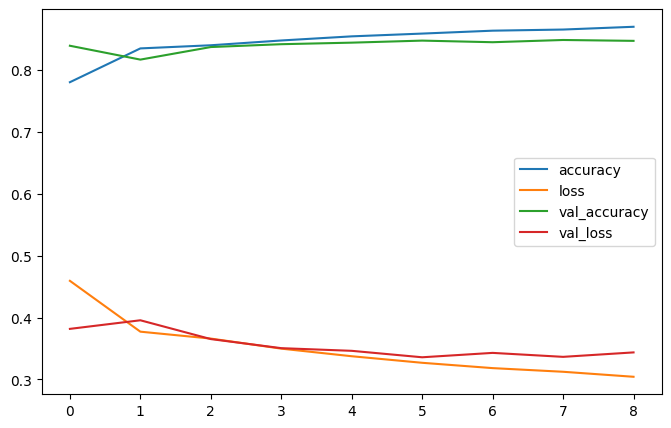

In [73]:
callback_early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_lematizado = model.fit(padded, 
                    train_labels,epochs=20, 
                    validation_data=(test_padded, test_labels),
                    callbacks=[callback_early])
pd.DataFrame(history_lematizado.history).plot(figsize=(8,5))

# Comparacion entre modelos! 